# BSPF 1D Differentiation Example

This notebook combines the simplified 1D differentiation example and its plotting workflow in one place.

It is adapted from the legacy `fig1_data.py` and `fig1_plot.py` scripts, but simplified to focus on the package API:

- uniform grid only,
- direct comparison between the BSPF derivative and the analytical derivative.

## Environment Setup

The next cell makes the notebook runnable directly from the repository checkout without requiring an editable install first.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = next((parent for parent in (cwd, *cwd.parents) if (parent / "pyproject.toml").exists()), cwd)
SRC_ROOT = REPO_ROOT / "src"

for candidate in (SRC_ROOT, REPO_ROOT):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

REPO_ROOT

PosixPath('/Users/moulin/Workspace/pybspf')

## Imports

We use the package API directly through `BSPF1D`.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from pybspf import BSPF1D

## Problem Definition

We use the nonlinear phase signal

$$
f(x) = \sin\left(\frac{x}{\beta + \cos(x)}\right)
$$

and compare the BSPF first derivative to the analytical derivative.

The parameter `beta = 1.05` is chosen to keep the problem well resolved on a uniform grid with 1001 points.

In [3]:
degree = 5
reg_param = 1.0e-3
beta = 1.05
domain = (0.0, 2.0 * np.pi)
num_points = 1001
num_boundary_points = degree + 1
n_basis = 3 * degree
use_clustering = True
clustering_factor = 2.0

In [4]:
def signal(x: np.ndarray, beta: float) -> np.ndarray:
    phase = x / (beta + np.cos(x))
    return np.sin(phase)


def signal_derivative(x: np.ndarray, beta: float) -> np.ndarray:
    denom = beta + np.cos(x)
    phase = x / denom
    dphase = (denom + x * np.sin(x)) / (denom**2)
    return np.cos(phase) * dphase


def relative_linf_error(approx: np.ndarray, exact: np.ndarray) -> float:
    return float(np.max(np.abs(approx - exact)) / np.max(np.abs(exact)))

## Single Run On A Uniform Grid

In [5]:
x = np.linspace(domain[0], domain[1], num_points)
y = signal(x, beta)
y_exact = signal_derivative(x, beta)

model = BSPF1D.from_grid(
    degree=degree,
    x=x,
    n_basis=n_basis,
    domain=domain,
    use_clustering=use_clustering,
    clustering_factor=clustering_factor,
    order=degree,
    num_boundary_points=num_boundary_points,
    correction="spectral",
)

y_deriv_bspf, y_spline = model.differentiate(y, k=1, lam=reg_param)
initial_relative_error = relative_linf_error(y_deriv_bspf, y_exact)
initial_relative_error

9.609572281466986e-12

## Convergence Sweep

This reproduces the basic convergence-study idea from the legacy workflow, but only for BSPF on the uniform grid.

In [6]:
grid_sizes = np.geomspace(100, 1000, 50).astype(int)
relative_errors = []
delta_x_values = []

for n_points in grid_sizes:
    x_test = np.linspace(domain[0], domain[1], n_points)
    y_test = signal(x_test, beta)
    y_exact_test = signal_derivative(x_test, beta)

    model_test = BSPF1D.from_grid(
        degree=degree,
        x=x_test,
        n_basis=n_basis,
        domain=domain,
        use_clustering=use_clustering,
        clustering_factor=clustering_factor,
        order=degree,
        num_boundary_points=num_boundary_points,
        correction="spectral",
    )
    y_deriv_test, _ = model_test.differentiate(y_test, k=1, lam=reg_param)

    relative_errors.append(relative_linf_error(y_deriv_test, y_exact_test))
    delta_x_values.append((domain[1] - domain[0]) / (n_points - 1))

relative_errors = np.array(relative_errors, dtype=np.float64)
delta_x_values = np.array(delta_x_values, dtype=np.float64)
relative_errors[:5]

array([1.08309274, 0.99202105, 0.98218328, 0.83637145, 0.94639957])

## Plot

The figure below summarizes the result directly in the notebook:

- signal and spline fit,
- exact and BSPF derivative,
- pointwise relative error,
- convergence sweep.

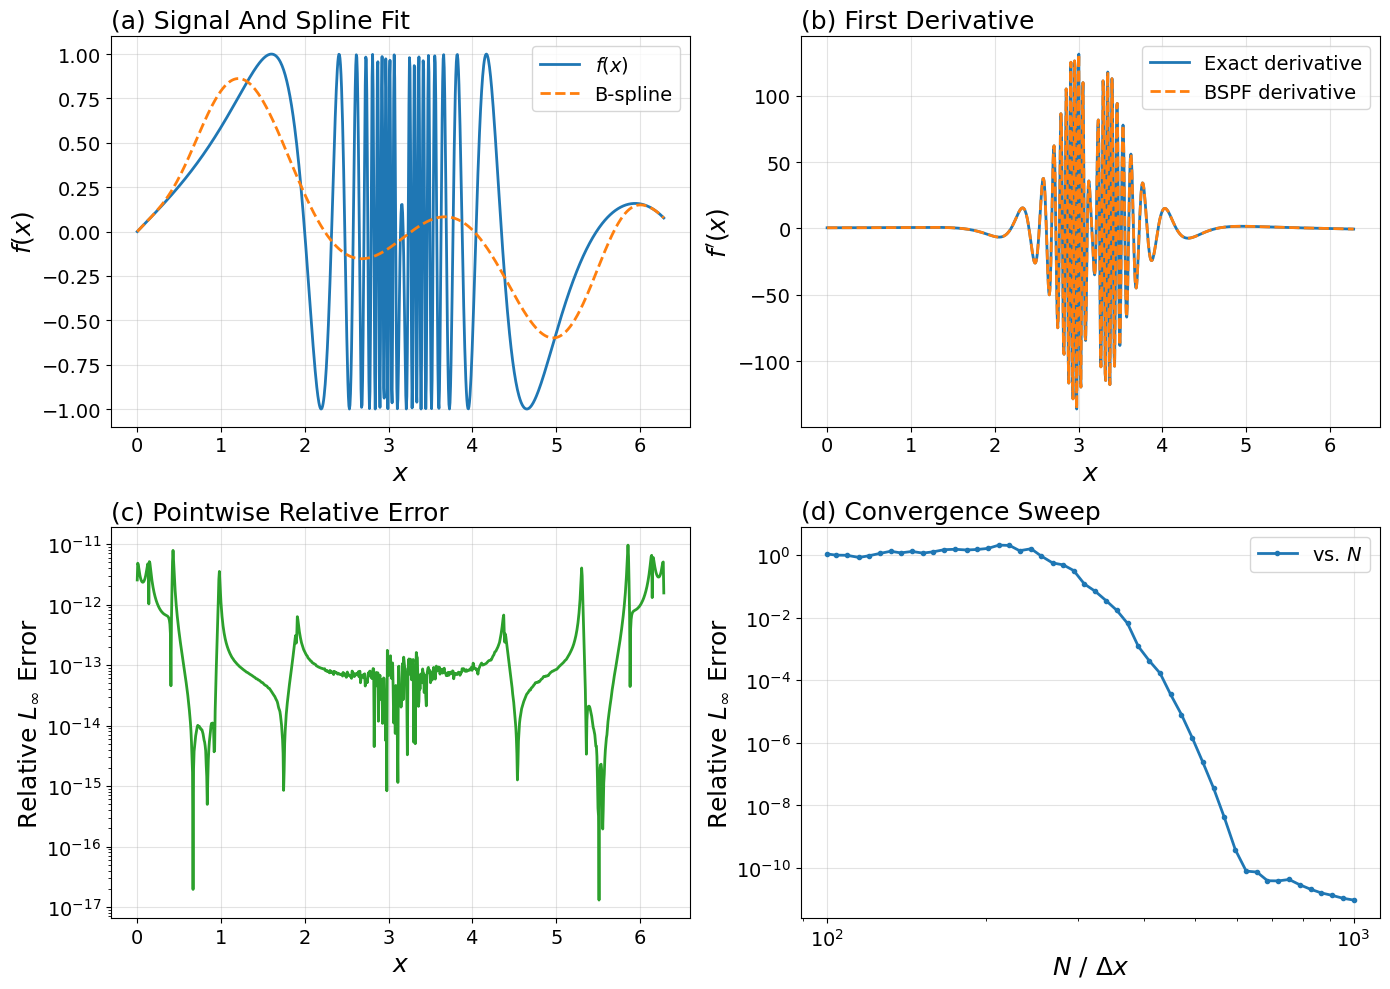

In [7]:
pointwise_relative_error = np.abs(y_deriv_bspf - y_exact) / np.max(np.abs(y_exact))

plt.rcParams.update(
    {
        "axes.labelsize": 18,
        "axes.titlesize": 18,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "figure.titlesize": 18,
        "axes.grid": True,
        "grid.alpha": 0.35,
    }
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

ax = axes[0, 0]
ax.plot(x, y, "-", color=default_colors[0], linewidth=2.0, label="$f(x)$")
ax.plot(x, y_spline, "--", color=default_colors[1], linewidth=2.0, label="B-spline")
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title("(a) Signal And Spline Fit", loc="left")
ax.legend(loc="best")

ax = axes[0, 1]
ax.plot(x, y_exact, "-", color=default_colors[0], linewidth=2.0, label="Exact derivative")
ax.plot(x, y_deriv_bspf, "--", color=default_colors[1], linewidth=2.0, label="BSPF derivative")
ax.set_xlabel("$x$")
ax.set_ylabel("$f'(x)$")
ax.set_title("(b) First Derivative", loc="left")
ax.legend(loc="best")

ax = axes[1, 0]
ax.plot(x, pointwise_relative_error, "-", color=default_colors[2], linewidth=2.0)
ax.set_xlabel("$x$")
ax.set_ylabel("Relative $L_\\infty$ Error")
ax.set_yscale("log")
ax.set_title("(c) Pointwise Relative Error", loc="left")

ax = axes[1, 1]
ax.loglog(grid_sizes, relative_errors, ".-", color=default_colors[0], linewidth=2.0, label="vs. $N$")
# ax.loglog(delta_x_values, relative_errors, ".-", color=default_colors[1], linewidth=2.0, label="vs. $\\Delta x$")
ax.set_xlabel("$N$ / $\\Delta x$")
ax.set_ylabel("Relative $L_\\infty$ Error")
ax.set_title("(d) Convergence Sweep", loc="left")
ax.legend(loc="best")

fig.tight_layout()
plt.show()